In [2]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.Descriptors import MolLogP
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.Chem import Descriptors
from rdkit.Chem import PandasTools
from rdkit.DataStructs import ExplicitBitVect

import sys
import multiprocessing
from standardiser import break_bonds, neutralise, rules, unsalt
from standardiser.utils import StandardiseException, sanity_check
def warn(*args, **kwargs):
    pass 
import warnings
warnings.filterwarnings("ignore")
warnings.warn = warn
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import sys
from sklearn.metrics import cohen_kappa_score
import csv
from rdkit.Chem import MACCSkeys
from sklearn.model_selection import ShuffleSplit
import _pickle as cPickle
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit    
import bz2
from glob import glob
import _pickle as cPickle
import pickle





In [3]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, rdMolDescriptors
from rdkit import RDLogger

#rdkit warn off
lg = RDLogger.logger()
lg.setLevel(RDLogger.CRITICAL)

# Function to read SDF file into DataFrame
def load_sdf_to_df(filename):
    suppl = Chem.SDMolSupplier(filename)
    rows = []
    for mol in suppl:
        if mol is not None:
            row = {prop: mol.GetProp(prop) for prop in mol.GetPropNames()}
            row['SMILES'] = Chem.MolToSmiles(mol)
            rows.append(row)
    return pd.DataFrame(rows)

# Load the train and test sets from SDF files
train_df = load_sdf_to_df(r'C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Respiratory Irritation\dataset\train_set_respiratory_irritation_features_rdkitcdk.sdf')
# Convert strings back to lists of integers
def string_to_list(bit_string):
    if isinstance(bit_string, str):
        return list(map(int, bit_string.strip('[]').split(', ')))
    else:
        return bit_string

train_df['Morgan_Descriptors'] = train_df['Morgan_Descriptors'].apply(string_to_list)
train_df['MACCS_Descriptors'] = train_df['MACCS_Descriptors'].apply(string_to_list)

# Modred handling calc
if 'Modred_Descriptor' in train_df.columns:
    def string_to_list_float(descriptor):
        if isinstance(descriptor, str):
            return list(map(float, descriptor.strip('[]').split(',')))
        return descriptor
    train_df['Modred_Descriptor'] = train_df['Modred_Descriptor'].apply(string_to_list_float)

print("Train DataFrame:")
print(train_df.head())
print(train_df.keys())


Train DataFrame:
                                                name Outcome    ID RowID  \
0  2-[2-[3-(carboxymethyl)-4-oxo-2-sulfanylidene-...       0  1832  1832   
1                                     propyl nitrate       1   773   773   
2  dipotassium;5-[[4-anilino-6-[bis(2-hydroxyethy...       0  2998  2998   
3                                           methanol       1    42    42   
4                           nickel(2+);diperchlorate       1  1760  1760   

                                  Morgan_Descriptors  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...   
2  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
3  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
4  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   MACCS_Descriptors  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
2  [0, 0, 0, 0, 0, 0,

Classes                          :  ['0' '1']
Number of cpds in each class     :  [1456 1477]
Total number of cpds             :  2933


{'0': 0, '1': 1}

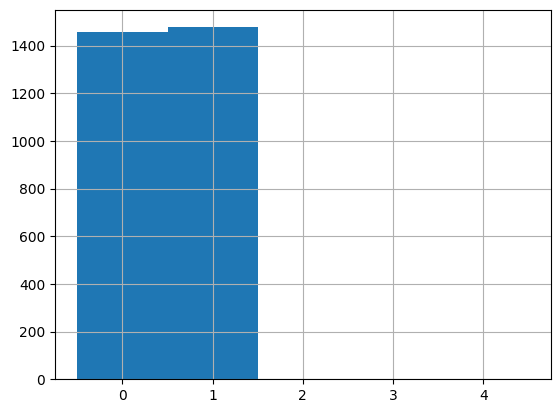

In [4]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()


outcomes=(np.unique(train_df['Outcome']))
le.fit(list(set(outcomes)))
y = le.transform( train_df['Outcome'] )



print ("Classes                          : ",(outcomes))
print ("Number of cpds in each class     : ",np.unique([len(y[y==smi]) for smi in y]))
print ("Total number of cpds             : ",len(y))

S =train_df['Outcome']
info = {}
for i,cls in enumerate(S.unique()):
    info.update({cls:i})
    S = S.replace(cls,i)

#graph
ax = S.hist(bins=np.arange(-0.5,5))
ax.set_xticks(range(0,5))
info

In [5]:
y= np.int32((S))
x = np.array(list(train_df['MACCS_Descriptors']))

print(x)

[[0 0 0 ... 1 1 0]
 [0 0 0 ... 1 0 0]
 [0 0 0 ... 1 1 1]
 ...
 [0 0 0 ... 1 1 1]
 [0 0 0 ... 1 0 1]
 [0 0 0 ... 1 1 0]]


In [10]:
#Random Forest
from sklearn.metrics import make_scorer, cohen_kappa_score
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier

paramgrid = {
    "max_features": [
        x.shape[1], x.shape[1] // 2, x.shape[1] // 4, x.shape[1] // 12, x.shape[1] // 10,
        x.shape[1] // 7, x.shape[1] // 5,
    ],
#     "n_estimators": [10, 100, 300, 500],
    "n_estimators": [100,200],
    "max_depth": [45,50],          

}


cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

# Define the scoring function using Cohen's Kappa Score with quadratic weighting
kappa_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

# Everything else remains the same in your GridSearchCV initialization and fitting
model_rf_maccskey = GridSearchCV(estimator=RandomForestClassifier(class_weight='balanced'),
                     param_grid=paramgrid,
                     scoring=kappa_scorer,
                     cv=cv,
                     verbose=1,
                     n_jobs=1)  # Use -1 to use all cores

# Fit the model
model_rf_maccskey.fit(x, y)

# Get the best model
best_model_rf_maccskey = model_rf_maccskey.best_estimator_


print("Best Params:", model_rf_maccskey.best_params_)
print("Best Score :", model_rf_maccskey.best_score_)

Fitting 5 folds for each of 28 candidates, totalling 140 fits
Best Params: {'max_depth': 50, 'max_features': 13, 'n_estimators': 200}
Best Score : 0.3458701648408022


In [11]:
#Random Forest
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np


seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    # Split data
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit the model
    best_model_rf_maccskey.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_rf_maccskey.predict(X_test)
    y_proba = best_model_rf_maccskey.predict_proba(X_test)[:, 1]  
    
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba)) 
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[196  96]
 [ 96 199]]
Confusion Matrix for Fold 2:
[[202  89]
 [ 97 199]]
Confusion Matrix for Fold 3:
[[188 103]
 [ 92 204]]
Confusion Matrix for Fold 4:
[[203  88]
 [ 97 198]]
Confusion Matrix for Fold 5:
[[194  97]
 [ 98 197]]
Overall CV Accuracy: 0.67507718427127
Overall CV AUC: 0.7250542249168377
Overall CV Precision: 0.6784838653867508
Overall CV Recall (Sensitivity): 0.6750091617040769
Overall CV F1 Score: 0.6766427806361908
Overall CV Specificity: 0.6751400461328438
Overall CV PPV (Positive Predictive Value): 0.6784838653867508
Overall CV NPV (Negative Predictive Value): 0.6718593921464677
Overall CV CCR (Correct Classification Rate): 0.6750746039184603


In [14]:
# SVM 
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

# Parameter grid 
paramgrid = {
     "C": [1,2,10],  # Regularization parameter
     "kernel": ['rbf'],  # Type of the kernel
     "gamma": ['scale', 'auto']  # Kernel coefficient
}

# 5-fold stratified shuffle split
cv = StratifiedShuffleSplit(
    n_splits=5,
    test_size=0.2,
    random_state=24
)

# Cohen’s Kappa 
kappa_scorer = make_scorer(
    cohen_kappa_score,
    weights="quadratic"
)

# GridSearchCV
model_svm_maccskey = GridSearchCV(
    estimator=SVC(probability=True,class_weight="balanced",random_state=24),
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    refit=True,
    verbose=1,
    n_jobs=-1
)

model_svm_maccskey.fit(x, y)
best_model_svm_maccskey = model_svm_maccskey.best_estimator_

print("Best Params:", model_svm_maccskey.best_params_)
print("Best Score :", model_svm_maccskey.best_score_)


Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Params: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best Score : 0.3769385396132744


In [15]:
#SVM
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np


seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    # Split data
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit the model
    best_model_svm_maccskey.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_svm_maccskey.predict(X_test)
    y_proba = best_model_svm_maccskey.predict_proba(X_test)[:, 1] 
    
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))  
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[199  93]
 [ 86 209]]
Confusion Matrix for Fold 2:
[[184 107]
 [ 77 219]]
Confusion Matrix for Fold 3:
[[168 123]
 [ 80 216]]
Confusion Matrix for Fold 4:
[[203  88]
 [ 91 204]]
Confusion Matrix for Fold 5:
[[198  93]
 [ 84 211]]
Overall CV Accuracy: 0.685653319069021
Overall CV AUC: 0.7421663903340938
Overall CV Precision: 0.6787418694368774
Overall CV Recall (Sensitivity): 0.7169697663765462
Overall CV F1 Score: 0.6968459333720045
Overall CV Specificity: 0.65382714305889
Overall CV PPV (Positive Predictive Value): 0.6787418694368774
Overall CV NPV (Negative Predictive Value): 0.6946499323672667
Overall CV CCR (Correct Classification Rate): 0.685398454717718


In [12]:
# XGB 
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

paramgrid = {
    "max_depth": [5,10],          
    "n_estimators": [230,260],           
    "learning_rate": [0.01,0.02],   
    "subsample": [0.8],              
    "colsample_bytree": [0.8],  
    "reg_lambda": [2,3]            
}

# 5-fold stratified CV
cv = StratifiedShuffleSplit(
    n_splits=5,
    test_size=0.2,
    random_state=24
)

# Cohen's Kappa 
kappa_scorer = make_scorer(cohen_kappa_score)

model_xgb_maccskey = GridSearchCV(
    estimator=XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=24,
        n_jobs=-1
    ),
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1
)

model_xgb_maccskey.fit(x, y)
best_model_xgb_maccskey = model_xgb_maccskey.best_estimator_

print("Best Params:", model_xgb_maccskey.best_params_)
print("Best Score :", model_xgb_maccskey.best_score_)


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 10, 'n_estimators': 260, 'reg_lambda': 3, 'subsample': 0.8}
Best Score : 0.3880228336403404


In [13]:
#XGB
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np

seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    # Split data
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit the model
    best_model_xgb_maccskey.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_xgb_maccskey.predict(X_test)
    y_proba = best_model_xgb_maccskey.predict_proba(X_test)[:, 1]  
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba)) 
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[198  94]
 [ 85 210]]
Confusion Matrix for Fold 2:
[[193  98]
 [ 87 209]]
Confusion Matrix for Fold 3:
[[174 117]
 [ 82 214]]
Confusion Matrix for Fold 4:
[[207  84]
 [ 92 203]]
Confusion Matrix for Fold 5:
[[205  86]
 [ 91 204]]
Overall CV Accuracy: 0.68769935636167
Overall CV AUC: 0.7446703108408819
Overall CV Precision: 0.6857724522865947
Overall CV Recall (Sensitivity): 0.7041158955565736
Overall CV F1 Score: 0.6944030613690682
Overall CV Specificity: 0.671011627359601
Overall CV PPV (Positive Predictive Value): 0.6857724522865947
Overall CV NPV (Negative Predictive Value): 0.6906990234541028
Overall CV CCR (Correct Classification Rate): 0.6875637614580871


In [22]:
#Neural Network 
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

# Parameter grid
paramgrid_nn = {
    "hidden_layer_sizes": [(200,150,400),(256,512,1024)],  
    "activation": ['relu'],             
    "solver": ['adam'],              
    "alpha": [0.0001,0.0003]                        
}

cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

kappa_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

model_nn_maccskey = GridSearchCV(
    estimator=MLPClassifier(max_iter=1000, random_state=42),
    param_grid=paramgrid_nn,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=1
)

# Fit the model
model_nn_maccskey.fit(x, y)
best_model_nn_maccskey = model_nn_maccskey.best_estimator_

print("Best Params:", model_nn_maccskey.best_params_)
print("Best Score :", model_nn_maccskey.best_score_)


Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Params: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (256, 512, 1024), 'solver': 'adam'}
Best Score : 0.308192764579417


In [21]:
#Neural Network NN
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np

seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit model
    best_model_nn_maccskey.fit(X_train, y_train)
    
    # Predictions
    y_pred = best_model_nn_maccskey.predict(X_test)
    y_proba = best_model_nn_maccskey.predict_proba(X_test)[:, 1]
    
    # Metrics
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity & Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV & NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Display Results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[208  84]
 [127 168]]
Confusion Matrix for Fold 2:
[[172 119]
 [ 86 210]]
Confusion Matrix for Fold 3:
[[131 160]
 [ 54 242]]
Confusion Matrix for Fold 4:
[[186 105]
 [ 87 208]]
Confusion Matrix for Fold 5:
[[197  94]
 [103 192]]
Overall CV Accuracy: 0.6525847282706654
Overall CV AUC: 0.7025840334480907
Overall CV Precision: 0.6485640002602129
Overall CV Recall (Sensitivity): 0.6904901511681173
Overall CV F1 Score: 0.6649618596512237
Overall CV Specificity: 0.613943416654898
Overall CV PPV (Positive Predictive Value): 0.6485640002602129
Overall CV NPV (Negative Predictive Value): 0.6667311290296365
Overall CV CCR (Correct Classification Rate): 0.6522167839115076


In [16]:
# LGBM 
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

# Parameter grid 
paramgrid = {
    "n_estimators": [200,230],
    "learning_rate": [0.005,0.1],
    "max_depth": [12,15],
    "num_leaves": [26],
    "min_child_samples": [20],
    "feature_fraction": [0.7],
    "bagging_fraction": [0.7],
    "bagging_freq": [1]
}

# Cross-validator 
cv = StratifiedShuffleSplit(
    n_splits=5,
    test_size=0.2,
    random_state=24
)

# Scoring function
kappa_scorer = make_scorer(
    cohen_kappa_score,
    weights='quadratic'
)

# GridSearchCV
model_lgbm_maccskey = GridSearchCV(
    estimator=LGBMClassifier(
        objective="binary",
        class_weight="balanced",
        verbosity=-1,
        force_row_wise=True,
        random_state=24
    ),
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=1
)

# fit model
model_lgbm_maccskey.fit(x, y)
best_model_lgbm_maccskey = model_lgbm_maccskey.best_estimator_

print("Best Params:", model_lgbm_maccskey.best_params_)
print("Best Score :", model_lgbm_maccskey.best_score_)


Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Params: {'bagging_fraction': 0.7, 'bagging_freq': 1, 'feature_fraction': 0.7, 'learning_rate': 0.005, 'max_depth': 12, 'min_child_samples': 20, 'n_estimators': 230, 'num_leaves': 26}
Best Score : 0.37301821647646916


In [17]:
# Evaluasi LGBM
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    precision_score, recall_score, f1_score
)
import numpy as np

seed = 42
np.random.seed(seed)

# Cross-validation setup
n_splits = 5
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Inisialisasi list metrik
accuracies, auc_scores, precisions, recalls, f1_scores = [], [], [], [], []
specificities, sensitivity_scores, ppvs, npvs, ccrs, confusion_matrices = [], [], [], [], [], []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit model 
    best_model_lgbm_maccskey.fit(X_train, y_train)
    
    # Predictions
    y_pred = best_model_lgbm_maccskey.predict(X_test)
    y_proba = best_model_lgbm_maccskey.predict_proba(X_test)[:, 1]
    
    # Metrics
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity & Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV & NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Display Results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[195  97]
 [ 86 209]]
Confusion Matrix for Fold 2:
[[194  97]
 [ 87 209]]
Confusion Matrix for Fold 3:
[[164 127]
 [ 80 216]]
Confusion Matrix for Fold 4:
[[205  86]
 [ 97 198]]
Confusion Matrix for Fold 5:
[[201  90]
 [ 88 207]]
Overall CV Accuracy: 0.6812211104069399
Overall CV AUC: 0.7352423275148987
Overall CV Precision: 0.6779806953572235
Overall CV Recall (Sensitivity): 0.7034333486028401
Overall CV F1 Score: 0.6898356266351856
Overall CV Specificity: 0.6586475544885374
Overall CV PPV (Positive Predictive Value): 0.6779806953572235
Overall CV NPV (Negative Predictive Value): 0.6861564923350667
Overall CV CCR (Correct Classification Rate): 0.6810404515456888


In [19]:
import joblib

base_path = r"C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Respiratory Irritation\model\fingerprint descriptor model"

joblib.dump(
    best_model_rf_maccskey,
    fr"{base_path}\Model_Respiratory_RF_maccskey.pkl",
    compress=9
)

joblib.dump(
    best_model_svm_maccskey,
    fr"{base_path}\Model_Respiratory_SVM_maccskey.pkl",
    compress=9
)

joblib.dump(
    best_model_xgb_maccskey,
    fr"{base_path}\Model_Respiratory_XGB_maccskey.pkl",
    compress=9
)

joblib.dump(
    best_model_lgbm_maccskey,
    fr"{base_path}\Model_Respiratory_LGBM_maccskey.pkl",
    compress=9
)


['C:\\Users\\User\\Documents\\KULIAH TELKOM S1\\SKRIPSI\\UJI COBA QSAR - PRIBADI\\Respiratory Irritation\\model\\fingerprint descriptor model\\Model_Respiratory_LGBM_maccskey.pkl']

In [23]:
joblib.dump(
    best_model_nn_maccskey,
    fr"{base_path}\Model_Respiratory_NN_maccskey.pkl",
    compress=9
)

['C:\\Users\\User\\Documents\\KULIAH TELKOM S1\\SKRIPSI\\UJI COBA QSAR - PRIBADI\\Respiratory Irritation\\model\\fingerprint descriptor model\\Model_Respiratory_NN_maccskey.pkl']